# Observed Stellar Spectrum Acquisition and Preparation

## Objective

The goal of this notebook is to select and prepare a high-quality observed stellar spectrum for Hβ line profile analysis.

The selected spectrum must satisfy:

- Solar-type star (F5-K2 V)
- SNR ≥ 50 near Hβ
- Suitable wavelength coverage around 4861 Å
- Publicly reproducible data source

# 1. Target Star Selection

## Selected Star

Star Name: 18 Scorpii

HD Number: HD 146233

Spectral Type: G2 V

Luminosity Class: Main Sequence (V)


## Reason for Selection

18 Scorpii is a well-studied solar twin star with atmospheric properties similar to the Sun.

It satisfies the project requirement of selecting a solar-type star (F5–K2, luminosity class V).

The star is suitable for Hβ line profile analysis because the Balmer line responds strongly to stellar effective temperature and surface gravity.

# 2. Observed Spectrum Archive Selection

The observed spectrum will be obtained from the ELODIE spectral library.

ELODIE is selected because:

- Spectra are already reduced.
- Spectra are wavelength calibrated.
- Spectra are radial velocity corrected.
- Spectra are normalized.
- The resolution is suitable for stellar atmospheric analysis.

Archive:

ELODIE Spectral Library

Reference:

Prugniel & Soubiran (2001)

# 3. Observed Spectrum Identification

## Target Star

Star Name:

18 Scorpii


HD Catalogue Number:

HD 146233


Spectral Type:

G2 V


## Archive Information

Archive:

ELODIE Stellar Library


Dataset:

20000327


Spectrum Identifier:

0030


File Name:

elodie_20000327_0030


Signal-to-Noise Ratio:

S/N = 237


The spectrum satisfies the project requirement of SNR ≥ 50 in the blue optical region.

The downloaded spectrum is a reduced, wavelength-calibrated stellar spectrum suitable for Hβ line profile analysis.

# 4. Inspecting the Observed Spectrum FITS File

The downloaded ELODIE spectrum is stored in FITS format.

The FITS file header contains important metadata including:

- Instrument information
- Wavelength calibration
- Spectral resolution
- Observation details

The file will be inspected using `astropy.io.fits`.

In [11]:
from astropy.io import fits

file_path = "../data/observed/ELODIE/elodie_20000327_0030.fits"

hdul = fits.open(file_path)

hdul.info()

Filename: ../data/observed/ELODIE/elodie_20000327_0030.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  INTENSITY     1 PrimaryHDU     109   (56000,)   float32   
  1  FCANOR        1 BinTableHDU     25   147R x 1C   [1E]   
  2  NOISE         1 ImageHDU       106   (56000,)   float32   


In [12]:
header = hdul[0].header

header

SIMPLE  =                    T / file does conform to FITS standard             
BITPIX  =                  -32 / No.Bits per pixel                              
NAXIS   =                    1 / number of data axes                            
NAXIS1  =                56000 / length of data axis 1                          
EXTEND  =                    T / FITS dataset may contain extensions            
COMMENT   FITS (Flexible Image Transport System) format is defined in 'Astronomy
COMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H 
COMMENT   FITS (Flexible Image Transport System) format is defined in 'Astronomy
COMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H 
COMMENT   FITS (Flexible Image Transport System) format is defined in 'Astronomy
COMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H 
COMMENT   FITS (Flexible Image Transport System) format is defined in 'Astronomy
COMMENT   and Astrophysics',

In [13]:
for key in header.keys():
    print(key, "=", header[key])

SIMPLE = True
BITPIX = -32
NAXIS = 1
NAXIS1 = 56000
EXTEND = True
COMMENT =   FITS (Flexible Image Transport System) format is defined in 'Astronomy
  and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H
  FITS (Flexible Image Transport System) format is defined in 'Astronomy
  and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H
  FITS (Flexible Image Transport System) format is defined in 'Astronomy
  and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H
  FITS (Flexible Image Transport System) format is defined in 'Astronomy
  and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H
= '*       '           / COMMENT
        The ELODIE archive (OHP)
 Note: The telescope position (POS1,POS2) and the catalogue information
(NOOBETn)
    may not be accurate. Please use instead the designation from keyword
 (OBJECT)
COMMENT =   FITS (Flexible Image Transport System) format is defined in 'Astronomy
  and Astrophysics', volume 37

# 5. Spectrum Properties

The important properties of the observed ELODIE spectrum were extracted from the FITS header.

## Wavelength Coverage

The spectrum contains 56000 pixels.

The wavelength calibration is:

Starting wavelength:
4000 Å

Pixel wavelength increment:
0.05 Å/pixel

The wavelength coverage is approximately:

4000 Å – 6800 Å


## Signal-to-Noise Ratio

The FITS header provides:

S/N = 236.8 per pixel at 550 nm.

This satisfies the project requirement:

SNR ≥ 50 near the blue optical region.


## Spectral Resolution

The wavelength resolution from the header is:

Δλ ≈ 0.132 Å

At the Hβ wavelength:

λ = 4861 Å

The resolving power is:

R = λ/Δλ

R ≈ 36,800

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Extract flux
flux = hdul[0].data

# Create wavelength array
header = hdul[0].header

start_wave = header["CRVAL1"]
step = header["CDELT1"]
pixels = header["NAXIS1"]

wavelength = start_wave + np.arange(pixels) * step

print("Wavelength range:")
print(wavelength[0], wavelength[-1])

print("Flux length:")
print(len(flux))

Wavelength range:
4000.0 6799.9500391993
Flux length:
56000


## 5.1 Full Observed Spectrum Visualization

The wavelength and flux arrays were used to visualize the complete observed spectrum of HD 146233.

The plot shows:

- The observed stellar flux across the full ELODIE wavelength range (4000–6800 Å).
- The position of the Hβ absorption line at 4861 Å marked with a vertical dashed line.

This visualization verifies that the downloaded spectrum is correctly loaded and identifies the spectral region used for further analysis.

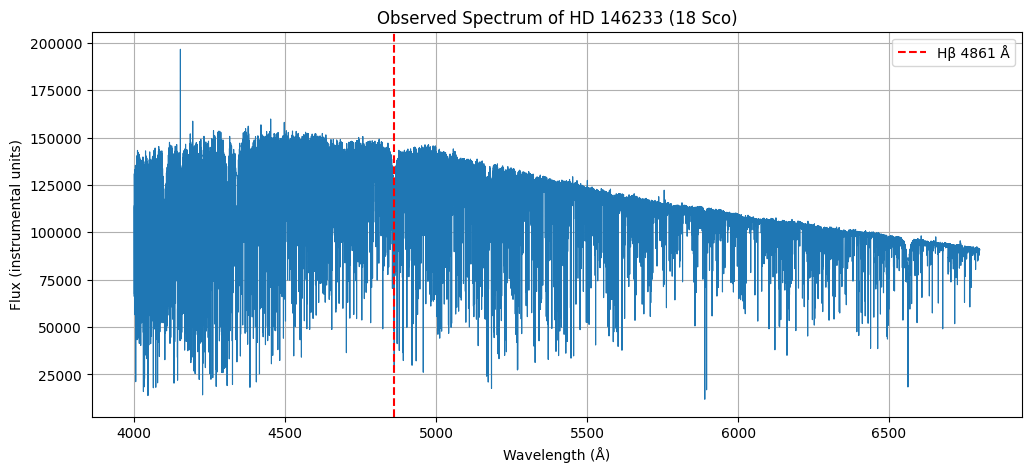

In [15]:
plt.figure(figsize=(12,5))

plt.plot(wavelength, flux, linewidth=0.8)

# Mark H beta line
plt.axvline(4861, color="red", linestyle="--", label="Hβ 4861 Å")

plt.xlabel("Wavelength (Å)")
plt.ylabel("Flux (instrumental units)")

plt.title("Observed Spectrum of HD 146233 (18 Sco)")

plt.legend()

plt.grid(True)

plt.show()

## 6. Hβ Spectral Region Extraction

The Hβ absorption line at 4861 Å is the primary spectral feature used for stellar atmospheric parameter determination.

A wavelength window of 4800–4900 Å was selected to isolate the Hβ line while including enough nearby continuum regions for normalization.

The extracted region will be used for continuum normalization and subsequent line profile fitting.

In [16]:
# Define Hβ wavelength region

hb_center = 4861.0

region_mask = (wavelength >= 4800) & (wavelength <= 4900)

hb_wavelength = wavelength[region_mask]
hb_flux = flux[region_mask]

print("Hβ wavelength range:")
print(hb_wavelength[0], hb_wavelength[-1])

print("Number of pixels:")
print(len(hb_flux))

Hβ wavelength range:
4800.0000112 4899.9500125993
Number of pixels:
2000


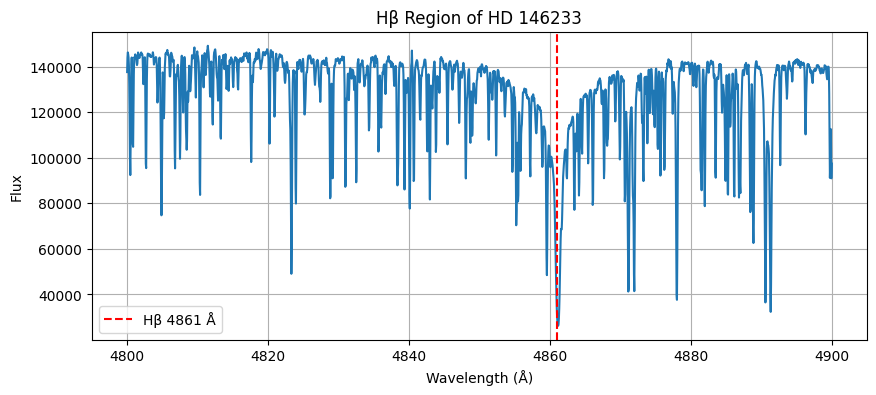

In [17]:
plt.figure(figsize=(10,4))

plt.plot(hb_wavelength, hb_flux)

plt.axvline(4861, color="red", linestyle="--", label="Hβ 4861 Å")

plt.xlabel("Wavelength (Å)")
plt.ylabel("Flux")

plt.title("Hβ Region of HD 146233")

plt.legend()
plt.grid(True)

plt.show()

## 7. Continuum Normalization of Hβ Region

The extracted Hβ region contains both the absorption line and the surrounding stellar continuum.

To prepare the spectrum for line profile fitting, the continuum level is normalized.

The continuum is estimated using regions outside the absorption feature and the spectrum is divided by this continuum.

After normalization, the continuum level is approximately equal to 1.

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Estimate continuum using upper percentile smoothing
continuum = np.percentile(hb_flux, 95)

# Normalize flux
hb_flux_norm = hb_flux / continuum


print("Estimated continuum:")
print(continuum)

print("Normalized flux range:")
print(hb_flux_norm.min(), hb_flux_norm.max())

Estimated continuum:
144932.33
Normalized flux range:
0.18113597 1.0296178


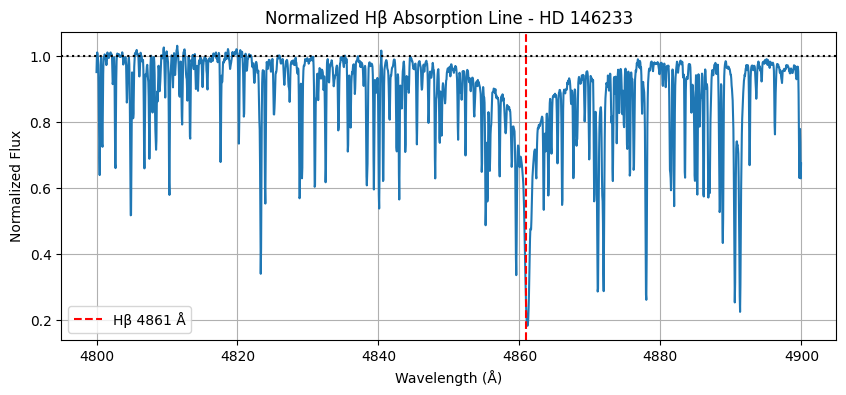

In [19]:
plt.figure(figsize=(10,4))

plt.plot(hb_wavelength, hb_flux_norm)

plt.axvline(4861, color="red", linestyle="--", label="Hβ 4861 Å")

plt.axhline(1.0, color="black", linestyle=":")

plt.xlabel("Wavelength (Å)")
plt.ylabel("Normalized Flux")

plt.title("Normalized Hβ Absorption Line - HD 146233")

plt.legend()
plt.grid(True)

plt.show()

## 7.1 Normalized Hβ Line Verification

The Hβ absorption line was successfully isolated and normalized.

After normalization, the continuum level is approximately equal to 1, while the absorption feature remains below the continuum level.

This normalized Hβ profile will be used later for comparison with synthetic PHOENIX spectra and stellar parameter fitting.

## 8. Saving Prepared Hβ Spectrum

The normalized Hβ spectrum was saved as a processed data file.

This allows later fitting steps to directly use the prepared observed spectrum without repeating the extraction and normalization process.

In [20]:
import numpy as np

output_path = "../data/observed/ELODIE/HD146233_Hbeta_normalized.txt"

np.savetxt(
    output_path,
    np.column_stack([hb_wavelength, hb_flux_norm]),
    header="Wavelength_Angstrom  Normalized_Flux"
)

print("Saved:", output_path)

Saved: ../data/observed/ELODIE/HD146233_Hbeta_normalized.txt
